<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_19_Monitoramento_e_Governanca_Professor_Resposta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 19 – Monitoramento e Governança
## Deep Learning e Inteligência Artificial Generativa Aplicada

### Capacidades
- Utilizar frameworks de Deep Learning.
- Zelar pelo uso de equipamentos, instrumentos, ferramentas e materiais.

### Conhecimentos
- Monitoramento de desempenho.
- Versionamento.
- Documentação técnica.
- Ética e governança.

### Estratégia
Análise de boas práticas e organização profissional de projetos.

### Recursos
GitHub, Ambiente Colab e Projetor.

### Evidência de aprendizagem
Repositório organizado.

### Versão do Professor — com solução comentada

## 1. Contextualização
Nesta aula, o estudante deixa de olhar apenas para o modelo funcionando e passa a olhar para o projeto de IA como produto técnico: monitorado, versionado, documentado, auditável e governado.

A situação-problema considera a empresa Alpha-SP, que possui modelos de IA em teste para falhas industriais, inspeção visual e chamados técnicos. A equipe precisa organizar um repositório profissional no GitHub e definir práticas de monitoramento e governança.

## 2. Conceitos principais

### Monitoramento
Acompanhamento contínuo de métricas como acurácia, precisão, recall, latência, volume de inferências, drift e incidentes.

### Drift
Mudança no comportamento dos dados ou da relação entre entrada e saída. Pode reduzir o desempenho do modelo ao longo do tempo.

### Versionamento
Registro histórico de alterações em código, notebooks, documentação, dependências, scripts, métricas e decisões técnicas.

### Governança e ética
Conjunto de regras para uso responsável da IA, considerando privacidade, segurança, transparência, rastreabilidade, validação humana e limites de uso.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Carregamento do dataset
O arquivo `aula19_dataset_monitoramento_modelos.csv` contém registros simulados de monitoramento de modelos.

In [3]:
# from google.colab import files
# files.upload()

df = pd.read_csv("/content/drive/MyDrive/Classroom/Deep Learning e Inteligência Artificial Generativa Aplicada/aula19_dataset_monitoramento_modelos.csv")
df.head()

,id_registro,modelo,versao,ambiente,responsavel,acuracia,precisao,recall,latencia_ms,volume_inferencias_dia,indice_drift,incidentes_reportados,status_monitoramento
0,1,modelo_nlp_chamados,v1.3.5,producao,equipe_automacao,0.9019,0.9062,0.9033,141.37,1767,0.3004,0,critico
1,2,modelo_cnn_inspecao,v1.0.9,producao,equipe_ti,0.8389,0.8756,0.8793,144.92,1946,0.1091,0,atencao
2,3,modelo_cnn_inspecao,v1.0.9,producao,equipe_qualidade,0.8499,0.8730,0.8274,455.22,1304,0.2814,2,critico
3,4,modelo_nlp_chamados,v1.1.8,producao,equipe_dados,0.8827,0.9109,0.8595,158.97,2645,0.1959,0,atencao
4,5,modelo_cnn_inspecao,v1.4.1,producao,equipe_qualidade,0.8688,0.8995,0.8581,324.13,2299,0.2125,0,atencao


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_registro             120 non-null    int64  
 1   modelo                  120 non-null    object 
 2   versao                  120 non-null    object 
 3   ambiente                120 non-null    object 
 4   responsavel             120 non-null    object 
 5   acuracia                120 non-null    float64
 6   precisao                120 non-null    float64
 7   recall                  120 non-null    float64
 8   latencia_ms             120 non-null    float64
 9   volume_inferencias_dia  120 non-null    int64  
 10  indice_drift            120 non-null    float64
 11  incidentes_reportados   120 non-null    int64  
 12  status_monitoramento    120 non-null    object 
dtypes: float64(5), int64(3), object(5)
memory usage: 12.3+ KB


In [5]:
df["status_monitoramento"].value_counts()

,count
status_monitoramento,
atencao,55
critico,51
ok,14


## 4. Análise dos indicadores de monitoramento
Vamos analisar desempenho, latência, drift e incidentes por modelo.

In [6]:
resumo_modelo = df.groupby("modelo").agg({
    "acuracia": "mean",
    "precisao": "mean",
    "recall": "mean",
    "latencia_ms": "mean",
    "indice_drift": "mean",
    "incidentes_reportados": "sum"
}).round(4)
resumo_modelo

,acuracia,precisao,recall,latencia_ms,indice_drift,incidentes_reportados
modelo,,,,,,
modelo_cnn_inspecao,0.8742,0.8732,0.8652,388.7144,0.1956,30
modelo_mlp_falhas,0.8614,0.8676,0.8437,377.0444,0.2271,25
modelo_nlp_chamados,0.8738,0.8651,0.8603,355.9468,0.2018,17


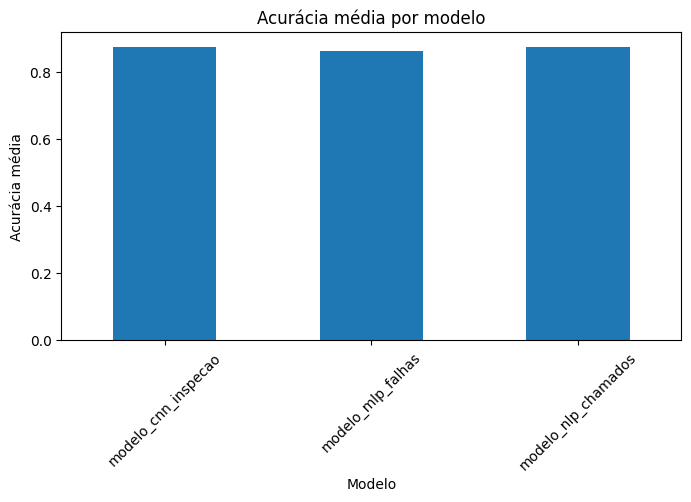

In [7]:
plt.figure(figsize=(8,4))
df.groupby("modelo")["acuracia"].mean().plot(kind="bar")
plt.title("Acurácia média por modelo")
plt.xlabel("Modelo")
plt.ylabel("Acurácia média")
plt.xticks(rotation=45)
plt.show()

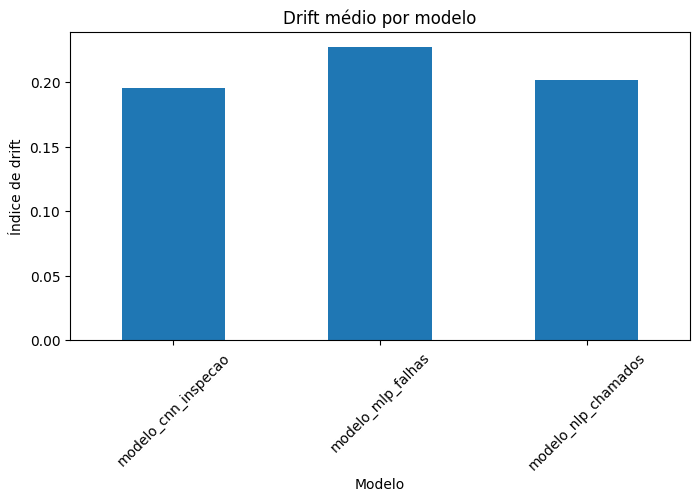

In [8]:
plt.figure(figsize=(8,4))
df.groupby("modelo")["indice_drift"].mean().plot(kind="bar")
plt.title("Drift médio por modelo")
plt.xlabel("Modelo")
plt.ylabel("Índice de drift")
plt.xticks(rotation=45)
plt.show()

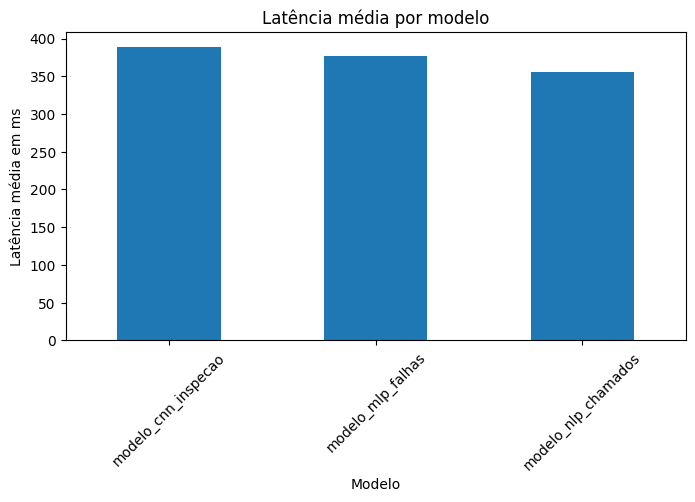

In [9]:
plt.figure(figsize=(8,4))
df.groupby("modelo")["latencia_ms"].mean().plot(kind="bar")
plt.title("Latência média por modelo")
plt.xlabel("Modelo")
plt.ylabel("Latência média em ms")
plt.xticks(rotation=45)
plt.show()

## 5. Regras de alerta
Regra didática:
- crítico: acurácia < 0.82, drift > 0.28 ou 3 ou mais incidentes;
- atenção: acurácia < 0.87, drift > 0.18 ou 1 ou mais incidente;
- ok: demais situações.

In [10]:
def classificar_status_monitoramento(linha):
    if linha["acuracia"] < 0.82 or linha["indice_drift"] > 0.28 or linha["incidentes_reportados"] >= 3:
        return "critico"
    elif linha["acuracia"] < 0.87 or linha["indice_drift"] > 0.18 or linha["incidentes_reportados"] >= 1:
        return "atencao"
    else:
        return "ok"

df["status_calculado"] = df.apply(classificar_status_monitoramento, axis=1)
df[["modelo", "versao", "acuracia", "indice_drift", "incidentes_reportados", "status_calculado"]].head(10)

,modelo,versao,acuracia,indice_drift,incidentes_reportados,status_calculado
0,modelo_nlp_chamados,v1.3.5,0.9019,0.3004,0,critico
1,modelo_cnn_inspecao,v1.0.9,0.8389,0.1091,0,atencao
2,modelo_cnn_inspecao,v1.0.9,0.8499,0.2814,2,critico
3,modelo_nlp_chamados,v1.1.8,0.8827,0.1959,0,atencao
4,modelo_cnn_inspecao,v1.4.1,0.8688,0.2125,0,atencao
5,modelo_mlp_falhas,v1.3.7,0.9359,0.3395,0,critico
6,modelo_nlp_chamados,v1.0.3,0.9124,0.1806,0,atencao
7,modelo_mlp_falhas,v1.1.2,0.9522,0.0748,1,atencao
8,modelo_nlp_chamados,v2.1.0,0.9382,0.2631,0,atencao
9,modelo_cnn_inspecao,v1.0.4,0.8442,0.1036,0,atencao


In [11]:
df["status_calculado"].value_counts()

,count
status_calculado,
atencao,55
critico,51
ok,14


## 6. Relatório técnico de monitoramento
Um repositório profissional deve conter evidências técnicas do comportamento do modelo.

In [12]:
def gerar_relatorio_monitoramento(df):
    total = len(df)
    criticos = (df["status_calculado"] == "critico").sum()
    atencao = (df["status_calculado"] == "atencao").sum()
    ok = (df["status_calculado"] == "ok").sum()
    maior_drift = df.groupby("modelo")["indice_drift"].mean().idxmax()
    maior_latencia = df.groupby("modelo")["latencia_ms"].mean().idxmax()
    menor_acuracia = df.groupby("modelo")["acuracia"].mean().idxmin()
    return f"""# Relatório Técnico de Monitoramento

## Resumo geral
Total de registros analisados: {total}

- Registros OK: {ok}
- Registros em atenção: {atencao}
- Registros críticos: {criticos}

## Pontos de atenção
- Modelo com maior drift médio: {maior_drift}
- Modelo com maior latência média: {maior_latencia}
- Modelo com menor acurácia média: {menor_acuracia}

## Recomendações
1. Revisar registros críticos.
2. Verificar mudança nos dados de entrada.
3. Avaliar retreinamento.
4. Conferir incidentes reportados.
5. Documentar decisões técnicas.
"""

relatorio_monitoramento = gerar_relatorio_monitoramento(df)
print(relatorio_monitoramento)

# Relatório Técnico de Monitoramento

## Resumo geral
Total de registros analisados: 120

- Registros OK: 14
- Registros em atenção: 55
- Registros críticos: 51

## Pontos de atenção
- Modelo com maior drift médio: modelo_mlp_falhas
- Modelo com maior latência média: modelo_cnn_inspecao
- Modelo com menor acurácia média: modelo_mlp_falhas

## Recomendações
1. Revisar registros críticos.
2. Verificar mudança nos dados de entrada.
3. Avaliar retreinamento.
4. Conferir incidentes reportados.
5. Documentar decisões técnicas.



In [13]:
Path("RELATORIO_MONITORAMENTO_AULA19.md").write_text(relatorio_monitoramento, encoding="utf-8")
print("Relatório salvo.")

Relatório salvo.


## 7. Estrutura profissional de repositório

```txt
projeto_ia_governanca/
├── README.md
├── requirements.txt
├── .gitignore
├── docs/
│   ├── RELATORIO_MONITORAMENTO_AULA19.md
│   ├── GOVERNANCA_IA.md
│   └── MODEL_CARD.md
├── notebooks/
├── src/
├── models/
├── data/
└── tests/
```

In [14]:
for pasta in [
    "projeto_ia_governanca/docs",
    "projeto_ia_governanca/notebooks",
    "projeto_ia_governanca/src",
    "projeto_ia_governanca/models",
    "projeto_ia_governanca/data",
    "projeto_ia_governanca/tests"
]:
    Path(pasta).mkdir(parents=True, exist_ok=True)
print("Estrutura criada.")

Estrutura criada.


## 8. Arquivos essenciais do repositório
Vamos criar `README.md`, `requirements.txt`, `.gitignore`, `MODEL_CARD.md`, `GOVERNANCA_IA.md` e `monitoring.py`.

In [15]:
readme = """# Projeto de IA — Monitoramento e Governança

## Objetivo
Organizar um projeto de IA com boas práticas de monitoramento, versionamento, documentação técnica e governança.

## Métricas monitoradas
Acurácia, precisão, recall, latência, volume de inferências, índice de drift e incidentes reportados.

## Governança e ética
O projeto deve respeitar privacidade, segurança, transparência, rastreabilidade e validação humana.

## Versão
v1.0.0
"""
Path("projeto_ia_governanca/README.md").write_text(readme, encoding="utf-8")
print("README.md criado.")

README.md criado.


In [16]:
requirements = """pandas
numpy
matplotlib
scikit-learn
fastapi
uvicorn
joblib
"""
Path("projeto_ia_governanca/requirements.txt").write_text(requirements, encoding="utf-8")
print(requirements)

pandas
numpy
matplotlib
scikit-learn
fastapi
uvicorn
joblib



In [17]:
gitignore = """venv/
.env/
.venv/
__pycache__/
*.pyc
.ipynb_checkpoints/
*.key
secrets.json
data/raw/
data/private/
*.h5
*.keras
*.joblib
*.pkl
"""
Path("projeto_ia_governanca/.gitignore").write_text(gitignore, encoding="utf-8")
print(".gitignore criado.")

.gitignore criado.


In [18]:
model_card = """# Model Card — Modelo de IA

## Nome do modelo
Modelo demonstrativo de classificação de falhas.

## Finalidade
Apoiar a identificação de possíveis falhas em contexto industrial.

## Limitações
- Pode perder desempenho se os dados mudarem.
- Não substitui avaliação técnica humana.

## Riscos
- Falso negativo em situação crítica.
- Falso positivo gerando manutenção desnecessária.

## Recomendações
Usar como apoio à decisão e monitorar periodicamente.
"""
Path("projeto_ia_governanca/docs/MODEL_CARD.md").write_text(model_card, encoding="utf-8")
print("MODEL_CARD.md criado.")

MODEL_CARD.md criado.


In [19]:
governanca = """# Governança de IA

## Objetivo
Definir boas práticas para uso, monitoramento e manutenção de modelos de IA.

## Responsabilidades
- Dados: análise de métricas e retreinamento.
- TI: infraestrutura, segurança e deploy.
- Negócio: validação de uso e impacto.

## Monitoramento
Monitorar desempenho, drift, latência, volume de inferências e incidentes.

## Ética e segurança
O modelo deve ser usado como apoio à decisão, com validação humana em situações críticas.
"""
Path("projeto_ia_governanca/docs/GOVERNANCA_IA.md").write_text(governanca, encoding="utf-8")
print("GOVERNANCA_IA.md criado.")

GOVERNANCA_IA.md criado.


In [20]:
monitoring_py = """def classificar_status(acuracia, indice_drift, incidentes_reportados):
    if acuracia < 0.82 or indice_drift > 0.28 or incidentes_reportados >= 3:
        return 'critico'
    elif acuracia < 0.87 or indice_drift > 0.18 or incidentes_reportados >= 1:
        return 'atencao'
    else:
        return 'ok'
"""
Path("projeto_ia_governanca/src/monitoring.py").write_text(monitoring_py, encoding="utf-8")
print("monitoring.py criado.")

monitoring.py criado.


## 9. Comandos Git básicos

```bash
git init
git status
git add .
git commit -m "Organiza estrutura inicial do projeto de IA"
git branch -M main
git remote add origin URL_DO_REPOSITORIO
git push -u origin main
```

In [21]:
comandos_git = [
    "git init",
    "git status",
    "git add .",
    'git commit -m "Organiza estrutura inicial do projeto de IA"',
    "git branch -M main",
    "git remote add origin URL_DO_REPOSITORIO",
    "git push -u origin main"
]
for comando in comandos_git:
    print(comando)

git init
git status
git add .
git commit -m "Organiza estrutura inicial do projeto de IA"
git branch -M main
git remote add origin URL_DO_REPOSITORIO
git push -u origin main


## 10. Checklist da evidência

In [22]:
checklist_repositorio = {
    "README.md": Path("projeto_ia_governanca/README.md").exists(),
    "requirements.txt": Path("projeto_ia_governanca/requirements.txt").exists(),
    ".gitignore": Path("projeto_ia_governanca/.gitignore").exists(),
    "docs/MODEL_CARD.md": Path("projeto_ia_governanca/docs/MODEL_CARD.md").exists(),
    "docs/GOVERNANCA_IA.md": Path("projeto_ia_governanca/docs/GOVERNANCA_IA.md").exists(),
    "src/monitoring.py": Path("projeto_ia_governanca/src/monitoring.py").exists(),
    "relatorio_monitoramento": Path("RELATORIO_MONITORAMENTO_AULA19.md").exists()
}
pd.DataFrame([checklist_repositorio]).T.rename(columns={0: "status"})

,status
README.md,True
requirements.txt,True
.gitignore,True
docs/MODEL_CARD.md,True
docs/GOVERNANCA_IA.md,True
src/monitoring.py,True
relatorio_monitoramento,True


## 11. Atividade prática avaliativa

Organize um repositório profissional contendo estrutura de pastas, README, requirements, .gitignore, documentação de governança, Model Card, relatório de monitoramento, script em `src/`, comandos Git e reflexão ética.

## 12. Questões para reflexão

1. Por que um modelo de IA precisa ser monitorado após entrar em uso?

Um modelo de IA precisa ser monitorado após entrar em uso para garantir que continue gerando resultados corretos e confiáveis ao longo do tempo.
Com o tempo, os dados podem mudar (data drift), afetando a precisão do modelo.
Também podem surgir novos padrões que o modelo não aprendeu durante o treinamento.
Além disso, é necessário identificar erros, vieses ou degradação de desempenho.
O monitoramento permite ajustes, re-treinamento e melhoria contínua.

2. Qual é a diferença entre versionar código e versionar modelo?

A diferença entre versionar código e versionar modelo está no tipo de artefato e no objetivo do controle de versões.
O versionamento de código registra alterações em scripts, algoritmos e lógica da aplicação.
Ele permite rastrear mudanças, colaborar em equipe e reverter versões do sistema.
Já o versionamento de modelo controla versões de modelos treinados, incluindo pesos, parâmetros e desempenho.
Permite comparar diferentes treinamentos e reproduzir resultados.

3. Por que o `.gitignore` é importante?

O arquivo .gitignore é importante porque define quais arquivos e pastas não devem ser versionados pelo Git.
Ele evita que arquivos desnecessários, temporários ou sensíveis (como logs, arquivos de configuração local e credenciais) sejam incluídos no repositório.
Isso mantém o projeto mais organizado, seguro e leve.
Também evita conflitos entre ambientes diferentes de desenvolvimento.

4. O que deve constar em uma documentação técnica de IA?

Uma documentação técnica de IA deve conter informações claras sobre como o modelo foi desenvolvido, utilizado e avaliado.
Deve incluir a descrição do problema e os objetivos da solução.
Também apresentar os dados utilizados (origem, tratamento e características).
É importante detalhar o modelo aplicado, parâmetros e arquitetura.
Deve conter métricas de avaliação de desempenho (acurácia, erro, etc.).
Além disso, incluir instruções de uso, implantação e manutenção.
Também pode abordar limitações, riscos e requisitos do sistema.

5. Quais riscos éticos devem ser considerados em projetos de IA?


Em projetos de IA, devem ser considerados diversos riscos éticos relacionados ao uso e impacto dos dados e decisões automatizadas.
Um dos principais é o viés algorítmico, que pode gerar decisões injustas ou discriminatórias.
Também há riscos relacionados à privacidade e proteção de dados, especialmente ao utilizar informações sensíveis.
A falta de transparência (caixa-preta) pode dificultar a explicação das decisões do modelo.
Existe ainda o risco de uso indevido ou mal-intencionado da tecnologia.
Além disso, decisões automatizadas sem supervisão podem causar impactos negativos.



In [23]:
respostas = {
    "1": "Porque o desempenho pode cair com mudanças nos dados, no processo ou no uso da aplicação.",
    "2": "Código registra implementação; modelo registra artefatos, métricas e decisões técnicas.",
    "3": "Evita enviar arquivos sensíveis, temporários, grandes ou inadequados.",
    "4": "Objetivo, dados, métricas, limitações, modo de uso, responsáveis, versões e riscos.",
    "5": "Privacidade, viés, uso indevido, falta de transparência e decisões automatizadas sem supervisão."
}
for k, v in respostas.items():
    print(f"{k}. {v}\n")

1. Porque o desempenho pode cair com mudanças nos dados, no processo ou no uso da aplicação.

2. Código registra implementação; modelo registra artefatos, métricas e decisões técnicas.

3. Evita enviar arquivos sensíveis, temporários, grandes ou inadequados.

4. Objetivo, dados, métricas, limitações, modo de uso, responsáveis, versões e riscos.

5. Privacidade, viés, uso indevido, falta de transparência e decisões automatizadas sem supervisão.



## 13. Critérios de avaliação

| Critério | Atingiu | Não atingiu |
|---|---|---|
| Organiza documentação adequadamente | Cria README, Model Card, governança e relatório técnico | Documentação ausente ou desorganizada |
| Aplica versionamento corretamente | Estrutura repositório, usa `.gitignore` e comandos Git coerentes | Não demonstra fluxo básico de versionamento |
| Demonstra compreensão ética do uso de IA | Aponta riscos, limites, privacidade e validação humana | Trata o modelo como solução infalível |
| Monitora desempenho | Analisa métricas, drift, latência e incidentes | Não acompanha indicadores |
| Organiza projeto profissional | Separa pastas, código, dados, docs e notebooks | Mantém arquivos soltos |